# DRUGseqPy — Notebook 2: Screen-Level Analysis

Continuing from `01_QC_Workflow.ipynb`, this notebook covers:
1. Batch correction (Harmony / DMSO-regression)
2. PCA, UMAP, and DMSO-anchored perturbation scoring
3. Parallelised differential expression for all compounds
4. Volcano, MA, and gene-count plots
5. Screen overview and logFC heatmap
6. Compound fingerprints and similarity network
7. Compound-level UMAP (DE-signature aggregation)
8. GSEA and connectivity scoring

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import anndata as ad

import drugseqpy as ds
from drugseqpy.utils import make_dummy_screen

sc.settings.verbosity = 1
plt.rcParams['figure.dpi'] = 100
print(f'drugseqpy v{ds.__version__}')

drugseqpy v0.1.0


## 0. Load filtered data from Notebook 1

In [2]:
# Load from Notebook 1 output:
# adata = ad.read_h5ad('dsd_qc_filtered.h5ad')
# dsd = ds.DrugSeqData(adata)

# Or rebuild from scratch for this tutorial:
counts, obs = make_dummy_screen(
    n_genes=500, n_plates=2,
    n_dmso_per_plate=10, n_compounds=6, n_reps=4, seed=42
)
dsd = ds.create_drugseq_object(counts=counts, obs=obs)
ds.compute_qc_metrics(dsd, inplace=True)
ds.compute_plate_qc(dsd, inplace=True)
ds.normalize_counts(dsd, method='limma_voom', inplace=True)
dsd = ds.filter_genes(dsd, min_count=5, min_samples=2, group_aware=True)
print(dsd)

DrugSeqData created: 500 genes × 68 samples across 2 plate(s).
  Found 6 mitochondrial and 12 ribosomal genes.
QC metrics computed for 68 samples.
Plate QC computed for 2 plate(s): 0 pass, 2 warn, 0 fail.
Normalizing 500 genes × 68 samples using limma_voom.
Normalization complete (method=limma_voom).
filter_genes: retaining 496 / 500 genes (4 removed).
  Low-expression removed: 4
DrugSeqData
  Samples   : 68
  Genes     : 496
  Plates    : 2
  Compounds : 7
  QC done   : True
  Normalized: limma_voom
  DE results: 0 compound(s)


/Users/frankhuang/Documents/HKU-RA/01.Library-Seq/20260317/drugseqpy/src/drugseqpy/qc.py:134: UserWarning: Only 0 housekeeping genes detected (need >= 5). Skipping HK metrics.
  warnings.warn(


## 1. PCA

Runs scanpy's PCA on normalized counts, selecting highly variable genes first.

In [3]:
ds.run_pca(dsd, n_pcs=50, n_variable_genes=300, inplace=True)

  Selected 300 highly variable genes.
PCA complete. Top PC: 5.7% variance; cumulative (10 PCs): 36.9%.


/Users/frankhuang/miniforge3/envs/drugseqpy/lib/python3.10/site-packages/scanpy/preprocessing/_pca/__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


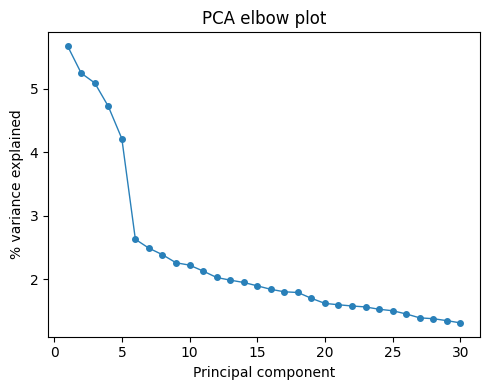

In [4]:
fig = ds.plot_pc_elbow(dsd, n_pcs=30)
plt.show()

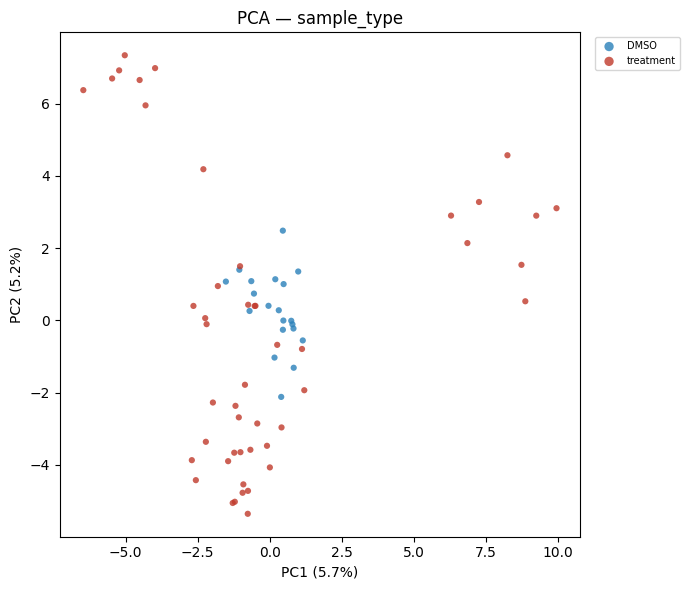

In [5]:
fig = ds.plot_embedding(dsd, reduction='X_pca', dims=(0, 1),
                         color_by='sample_type')
plt.show()

## 2. Batch correction

Harmony corrects PCA embeddings across plates without modifying normalized counts.

Applying batch correction: method=harmony, batch_col=plate_id


2026-03-31 16:58:36,428 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
/Users/frankhuang/miniforge3/envs/drugseqpy/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/frankhuang/miniforge3/envs/drugseqpy/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/frankhuang/miniforge3/envs/drugseqpy/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
2026-03-31 16:58:36,459 - harmonypy - INFO - KMeans initialization complete.


  Harmony corrected PCA stored in obsm['X_pca_harmony'] (30 dims).
Batch correction complete.


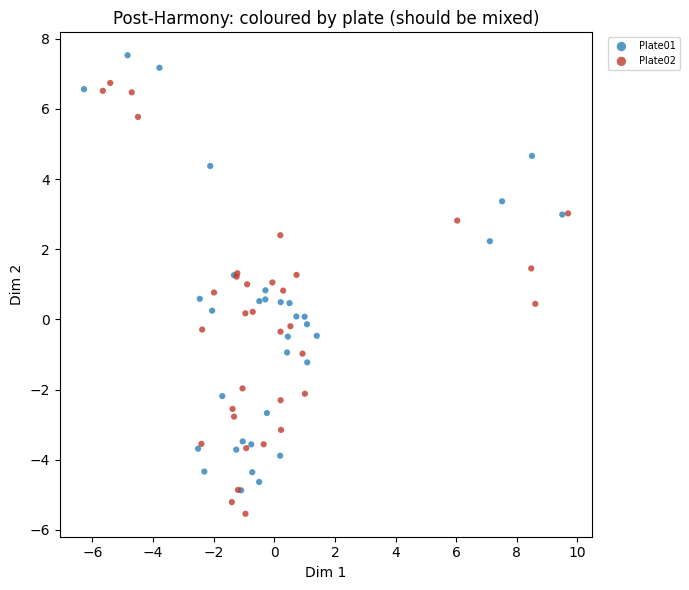

In [6]:
# Harmony integration (corrects X_pca → X_pca_harmony)
ds.correct_batch(dsd, batch_col='plate_id', method='harmony', n_pcs=30, inplace=True)

# Check: post-Harmony PCA should cluster by compound, not plate
fig = ds.plot_embedding(dsd, reduction='X_pca_harmony', dims=(0, 1),
                         color_by='plate_id')
plt.title('Post-Harmony: coloured by plate (should be mixed)')
plt.show()

In [7]:
# Alternative: DMSO-regression (Drug-seq native; corrects adata.X directly)
# ds.correct_batch(dsd, batch_col='plate_id', method='dmso_regression', inplace=True)

## 3. UMAP

In [8]:
ds.run_umap(dsd, dims=20, n_neighbors=15, min_dist=0.3,
             use_harmony=True, inplace=True)

/Users/frankhuang/miniforge3/envs/drugseqpy/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


UMAP complete (n_neighbors=15, min_dist=0.3).


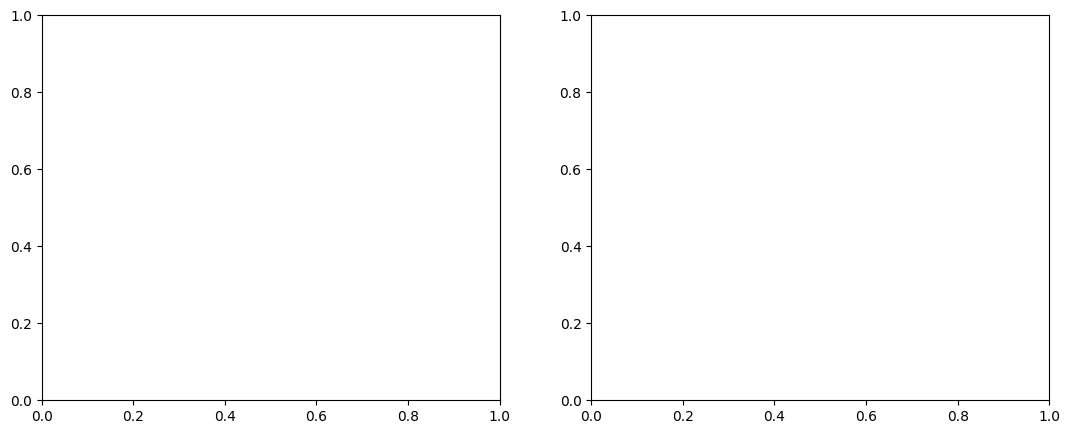

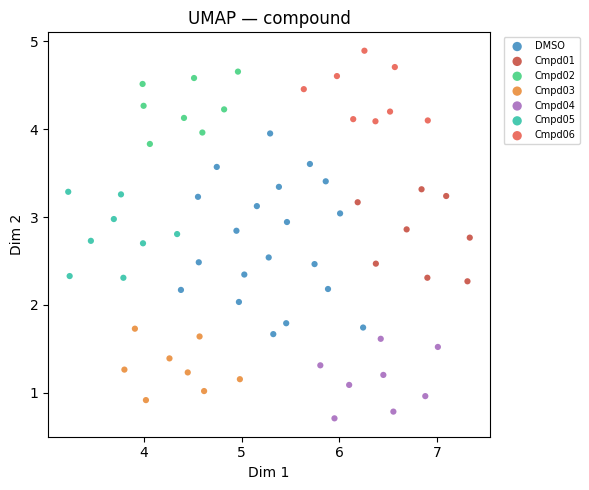

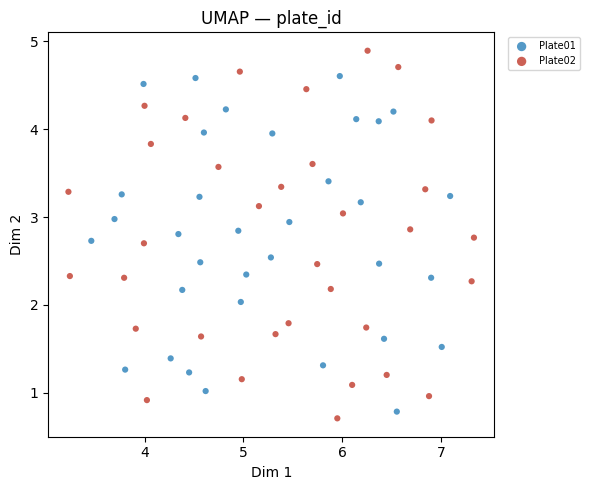

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, col in zip(axes, ['compound', 'plate_id']):
    ds.plot_embedding(dsd, reduction='X_umap', color_by=col, figsize=(6,5))
plt.tight_layout()
plt.show()

## 4. DMSO-anchored perturbation scoring

Fits PCA on DMSO wells only, projects all samples into that space, and
computes a z-scored distance from the DMSO centroid.  High `pert_score` → strong transcriptional response.

embedDMSO: fitting PCA on 20 DMSO wells.
embedDMSO complete. 'pert_score' reflects perturbation from DMSO centroid.


/Users/frankhuang/miniforge3/envs/drugseqpy/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/frankhuang/miniforge3/envs/drugseqpy/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/frankhuang/miniforge3/envs/drugseqpy/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T
/Users/frankhuang/miniforge3/envs/drugseqpy/lib/python3.10/site-packages/sklearn/decomposition/_base.py:155: RuntimeWarning: divide by zero encountered in matmul
  X_transformed -= xp.reshape(self.mean_, (1, -1)) @ self.components_.T
/Users/frankhuang/miniforge3/envs/drugseqpy/lib/python3.10/site-packages/sklearn/decomposition/_base.py:155: RuntimeWarning: overflow encountered in matmul
  X_tran

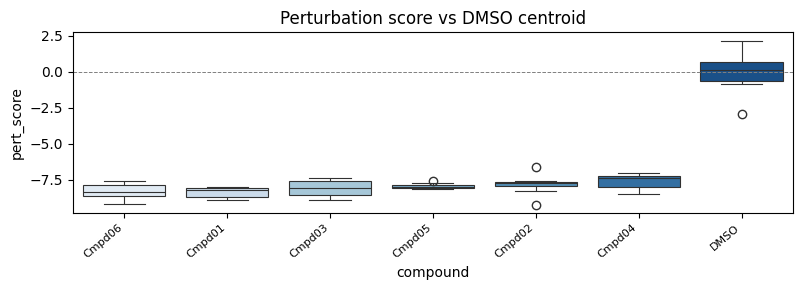

In [10]:
ds.embed_dmso(dsd, n_pcs=15, n_variable_genes=300, inplace=True)

# Distribution of perturbation scores
import seaborn as sns
fig, ax = plt.subplots(figsize=(8, 3))
df_pert = dsd.obs[['compound', 'sample_type', 'pert_score']]
order = df_pert.groupby('compound')['pert_score'].median().sort_values().index
sns.boxplot(data=df_pert, x='compound', y='pert_score', order=order, ax=ax,
            palette='Blues', linewidth=0.8)
ax.axhline(0, color='grey', linestyle='--', linewidth=0.7)
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=8)
ax.set_title('Perturbation score vs DMSO centroid')
plt.tight_layout()
plt.show()

## 5. Differential expression

All compounds vs DMSO, parallelised via `n_jobs`.
- **pydeseq2** (default): Python port of DESeq2 — best for count data
- **ols_voom**: OLS on voom log-CPM — equivalent to limma-voom in R
- **t_test**: fast screening

In [11]:
ds.compute_multi_de(
    dsd,
    reference='DMSO',
    method='ols_voom',   # or 'pydeseq2'
    within_plate=True,
    fdr_threshold=0.05,
    lfc_threshold=0.5,
    n_jobs=1,            # increase for large screens
    inplace=True,
)

compute_multi_de: testing 6 compound(s) using 1 worker(s) [ols_voom].
compute_multi_de complete: 6 / 6 compounds processed.


/Users/frankhuang/Documents/HKU-RA/01.Library-Seq/20260317/drugseqpy/src/drugseqpy/differential.py:143: RuntimeWarning: divide by zero encountered in matmul
  beta = XtX_inv @ X.T @ log_cpm         # (2, n_genes)
/Users/frankhuang/Documents/HKU-RA/01.Library-Seq/20260317/drugseqpy/src/drugseqpy/differential.py:143: RuntimeWarning: overflow encountered in matmul
  beta = XtX_inv @ X.T @ log_cpm         # (2, n_genes)
/Users/frankhuang/Documents/HKU-RA/01.Library-Seq/20260317/drugseqpy/src/drugseqpy/differential.py:143: RuntimeWarning: invalid value encountered in matmul
  beta = XtX_inv @ X.T @ log_cpm         # (2, n_genes)
/Users/frankhuang/Documents/HKU-RA/01.Library-Seq/20260317/drugseqpy/src/drugseqpy/differential.py:144: RuntimeWarning: divide by zero encountered in matmul
  fitted = X @ beta
/Users/frankhuang/Documents/HKU-RA/01.Library-Seq/20260317/drugseqpy/src/drugseqpy/differential.py:144: RuntimeWarning: overflow encountered in matmul
  fitted = X @ beta
/Users/frankhuang/Do

In [12]:
# Summary table: one row per compound
de_sum = ds.summarise_de(dsd)
de_sum.sort_values('n_sig_total', ascending=False)

,compound,n_tested,n_sig_up,n_sig_down,n_sig_total,top_gene,min_padj
0,Cmpd01,496,10,1,11,Gene0007,1.106838e-07
2,Cmpd03,496,10,1,11,Gene0029,4.071879e-09
1,Cmpd02,496,10,0,10,Gene0015,2.231970e-08
3,Cmpd04,496,10,0,10,Gene0032,2.483353e-12
4,Cmpd05,496,10,0,10,Gene0044,4.964422e-07
5,Cmpd06,496,10,0,10,Gene0053,1.225329e-08


## 6. Volcano and MA plots

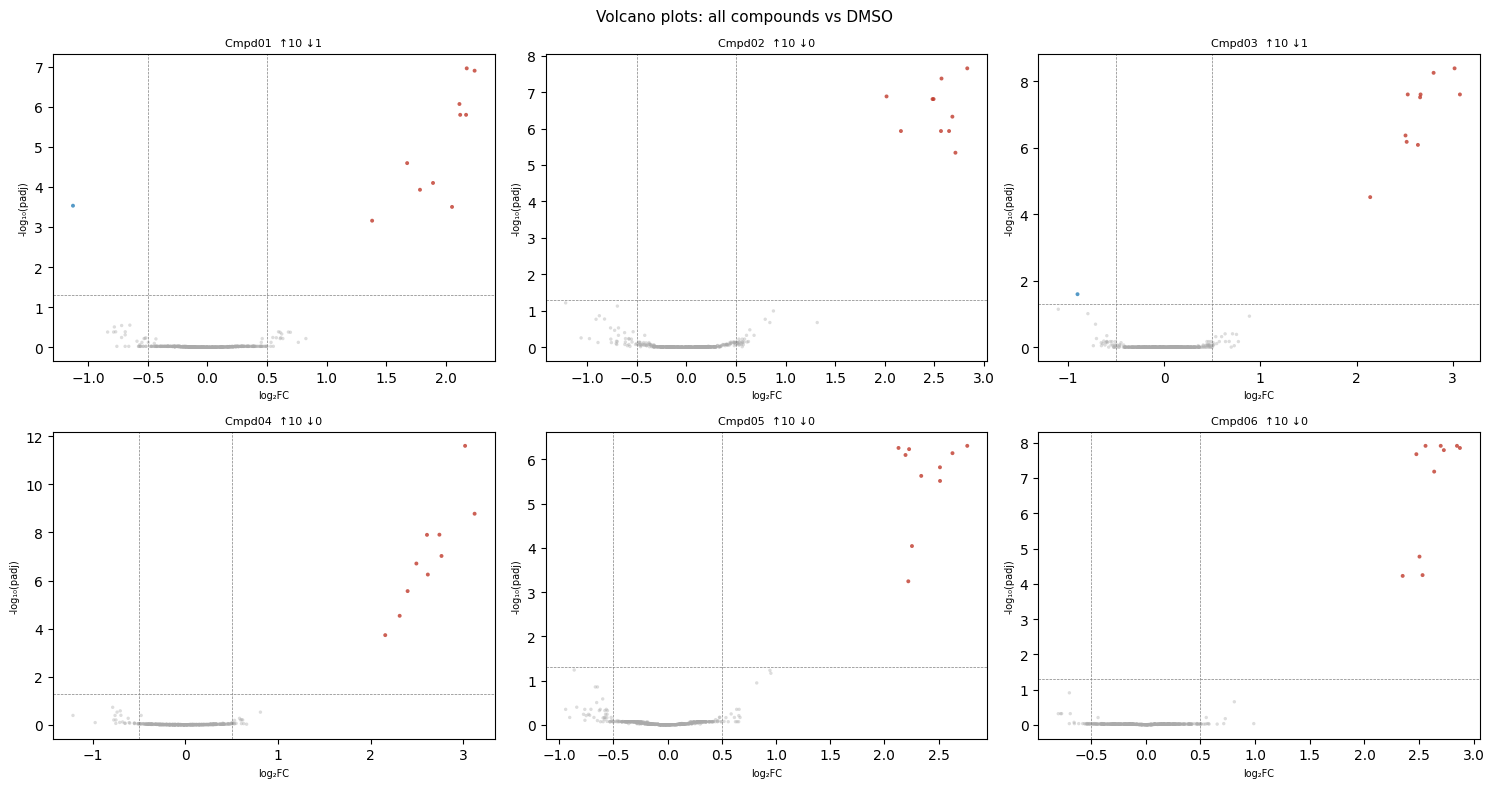

In [13]:
# Plot for each compound in a grid
compounds = list(dsd.adata.uns['de_results'].keys())
n_cpds = len(compounds)
ncol = 3
nrow = int(np.ceil(n_cpds / ncol))

fig, axes = plt.subplots(nrow, ncol, figsize=(ncol*5, nrow*4))
for ax, cmpd in zip(axes.ravel(), compounds):
    df = dsd.adata.uns['de_results'][cmpd].copy()
    df['-log10_padj'] = -np.log10(df['padj'].clip(1e-300))
    sig = df['significant'].fillna(False)
    ax.scatter(df.loc[~sig,'logFC'], df.loc[~sig,'-log10_padj'],
               s=6, alpha=0.4, color='#AAAAAA', edgecolors='none')
    ax.scatter(df.loc[sig & (df.logFC>0),'logFC'], df.loc[sig & (df.logFC>0),'-log10_padj'],
               s=8, alpha=0.8, color='#C0392B', edgecolors='none')
    ax.scatter(df.loc[sig & (df.logFC<0),'logFC'], df.loc[sig & (df.logFC<0),'-log10_padj'],
               s=8, alpha=0.8, color='#2980B9', edgecolors='none')
    ax.axvline(-0.5, color='grey', linestyle='--', lw=0.5)
    ax.axvline( 0.5, color='grey', linestyle='--', lw=0.5)
    ax.axhline(-np.log10(0.05), color='grey', linestyle='--', lw=0.5)
    n_up = int((sig & (df.logFC>0)).sum())
    n_dn = int((sig & (df.logFC<0)).sum())
    ax.set_title(f'{cmpd}  ↑{n_up} ↓{n_dn}', fontsize=8)
    ax.set_xlabel('log₂FC', fontsize=7)
    ax.set_ylabel('-log₁₀(padj)', fontsize=7)

for ax in axes.ravel()[n_cpds:]:
    ax.set_visible(False)
fig.suptitle('Volcano plots: all compounds vs DMSO', fontsize=11)
plt.tight_layout()
plt.show()

/Users/frankhuang/Documents/HKU-RA/01.Library-Seq/20260317/drugseqpy/src/drugseqpy/screen.py:513: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x="group", y="expression",
/Users/frankhuang/Documents/HKU-RA/01.Library-Seq/20260317/drugseqpy/src/drugseqpy/screen.py:513: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x="group", y="expression",
/Users/frankhuang/Documents/HKU-RA/01.Library-Seq/20260317/drugseqpy/src/drugseqpy/screen.py:513: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x="group", y="expression",
/

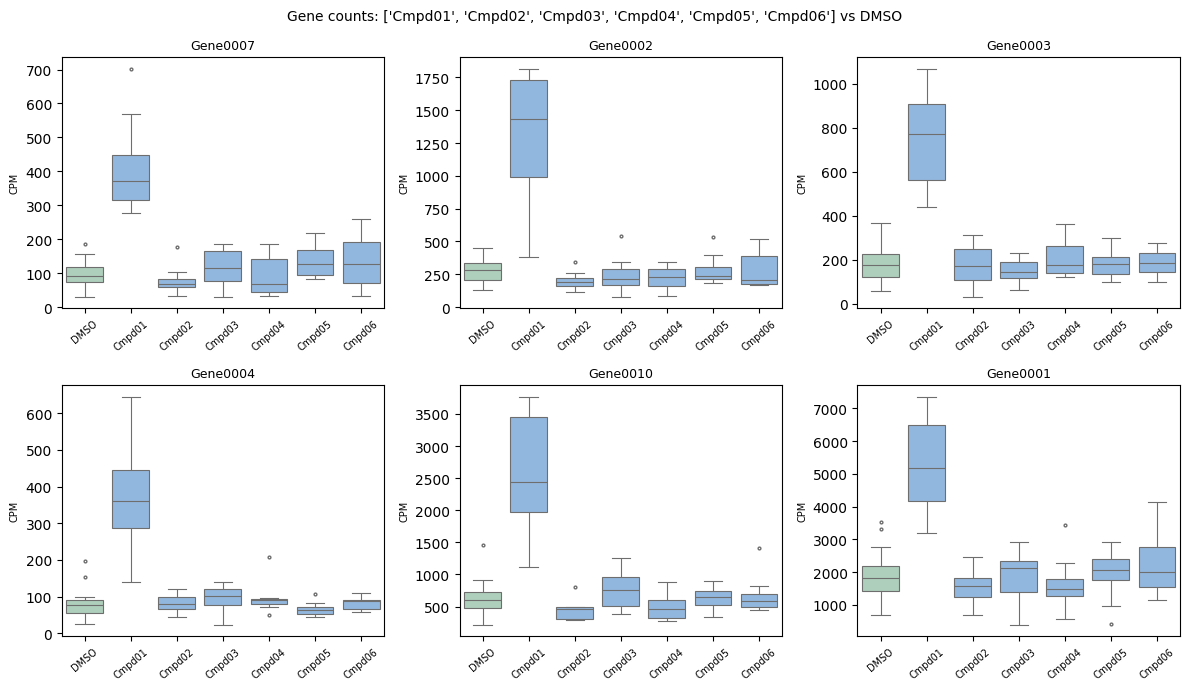

In [14]:
# Gene-count box plots for specific genes of interest
sig_genes = (
    dsd.adata.uns['de_results'][compounds[0]]
    .query('significant == True')
    .nsmallest(6, 'padj')['gene'].tolist()
)

if sig_genes:
    fig = ds.plot_gene_counts(dsd, genes=sig_genes, group_by='compound')
    plt.show()
else:
    print('No significant genes at default thresholds (expected with synthetic data)')

## 7. Screen overview and logFC heatmap

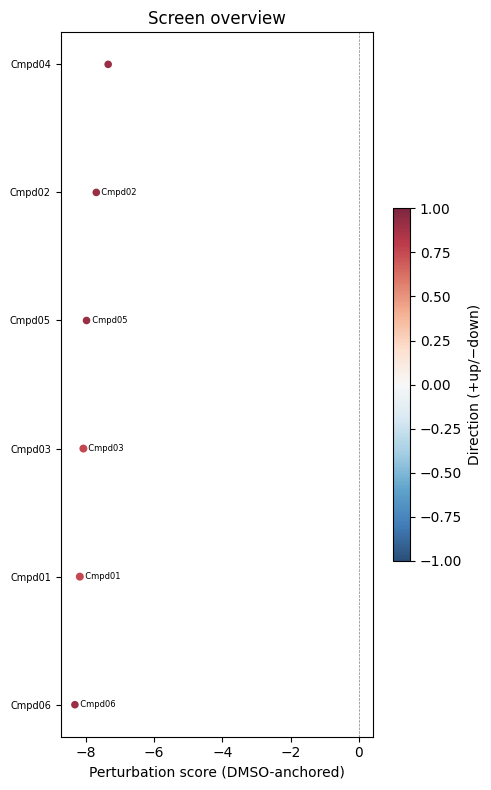

In [15]:
# Screen overview: perturbation score × DE count × direction
fig = ds.plot_screen_overview(
    dsd,
    fdr_threshold=0.05, lfc_threshold=0.5,
    use_pert_score=True,
    top_n_label=5,
)
plt.show()

<Figure size 600x600 with 0 Axes>

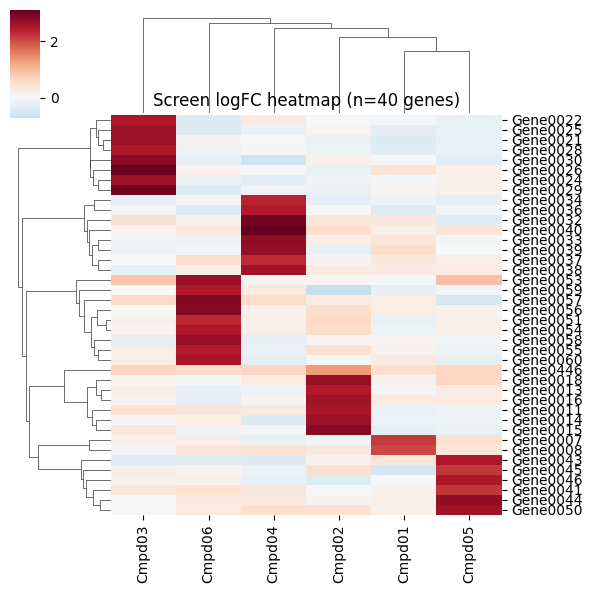

In [16]:
# LogFC heatmap across all compounds (macpie::plot_multi_de)
try:
    fig = ds.plot_screen_heatmap(dsd, n_top=40, fdr_threshold=1.0)
    plt.show()
except Exception as e:
    print(f'Heatmap skipped: {e}')

## 8. Compound fingerprints and similarity network

In [17]:
# Signed binary {-1, 0, +1} fingerprint matrix
fp = ds.compute_compound_fingerprint(dsd, fdr_threshold=0.1, lfc_threshold=0.3)
print(f'Fingerprint matrix: {fp.shape[0]} genes × {fp.shape[1]} compounds')
print(f'Unique values: {sorted(fp.values.ravel())[:4]}…')

Fingerprint matrix: 67 genes × 6 compounds
Unique values: [np.int8(-1), np.int8(-1), np.int8(-1), np.int8(-1)]…


/Users/frankhuang/Documents/HKU-RA/01.Library-Seq/20260317/drugseqpy/src/drugseqpy/enrichment.py:237: RuntimeWarning: divide by zero encountered in matmul
  return norm_A.T @ norm_B
/Users/frankhuang/Documents/HKU-RA/01.Library-Seq/20260317/drugseqpy/src/drugseqpy/enrichment.py:237: RuntimeWarning: overflow encountered in matmul
  return norm_A.T @ norm_B
/Users/frankhuang/Documents/HKU-RA/01.Library-Seq/20260317/drugseqpy/src/drugseqpy/enrichment.py:237: RuntimeWarning: invalid value encountered in matmul
  return norm_A.T @ norm_B


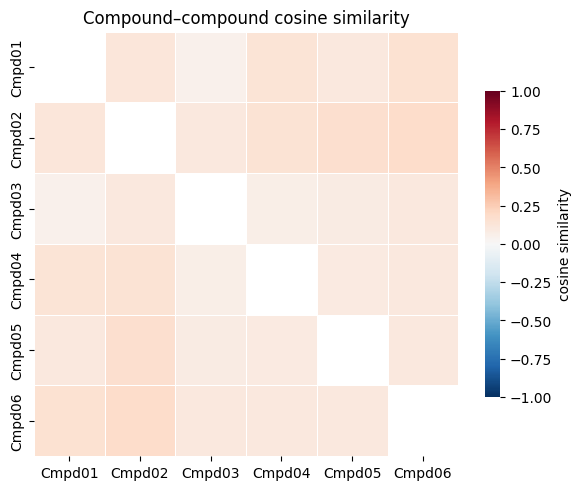

In [18]:
# Cosine similarity between compound DE signatures
sim = ds.connectivity_score(dsd, method='cosine')
sim_df = pd.DataFrame(sim,
                       index=list(dsd.adata.uns['de_results'].keys()),
                       columns=list(dsd.adata.uns['de_results'].keys()))

import seaborn as sns
fig, ax = plt.subplots(figsize=(6, 5))
mask = np.eye(len(sim_df), dtype=bool)
sns.heatmap(sim_df, cmap='RdBu_r', center=0, ax=ax, mask=mask,
            vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={'label': 'cosine similarity', 'shrink': 0.7})
ax.set_title('Compound–compound cosine similarity')
plt.tight_layout()
plt.show()

Compound network: 6 nodes, 15 edges, 6 Leiden communities (threshold=0.00).


/Users/frankhuang/Documents/HKU-RA/01.Library-Seq/20260317/drugseqpy/src/drugseqpy/enrichment.py:237: RuntimeWarning: divide by zero encountered in matmul
  return norm_A.T @ norm_B
/Users/frankhuang/Documents/HKU-RA/01.Library-Seq/20260317/drugseqpy/src/drugseqpy/enrichment.py:237: RuntimeWarning: overflow encountered in matmul
  return norm_A.T @ norm_B
/Users/frankhuang/Documents/HKU-RA/01.Library-Seq/20260317/drugseqpy/src/drugseqpy/enrichment.py:237: RuntimeWarning: invalid value encountered in matmul
  return norm_A.T @ norm_B


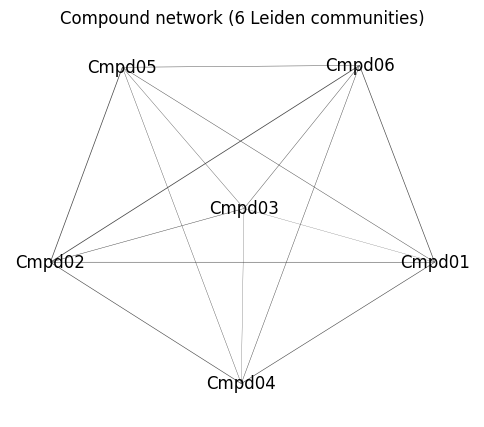

In [19]:
# Similarity network (requires igraph for Leiden clustering)
net = ds.compute_compound_similarity_network(dsd, method='cosine', threshold=0.0)

if net['graph'] is not None:
    import igraph as ig
    import matplotlib.pyplot as plt
    g = net['graph']
    clusters = net['clusters']
    n_clusters = clusters.nunique()
    palette = plt.cm.tab10(np.linspace(0, 1, n_clusters))
    color_map = dict(zip(sorted(clusters.unique()), palette))
    colors = [color_map[clusters[v['name']]] for v in g.vs]
    fig, ax = plt.subplots(figsize=(6, 5))
    ig.plot(g, target=ax,
            vertex_label=g.vs['name'],
            vertex_color=[list(c) for c in colors],
            edge_width=[g.es['weight'][i] * 3 for i in range(g.ecount())],
            vertex_size=0.4, layout='fr')
    ax.set_title(f'Compound network ({n_clusters} Leiden communities)')
    plt.show()
else:
    print('Install igraph for network visualization: pip install igraph')

## 9. Compound-level UMAP on DE signatures

Aggregates replicate log-fold-changes into compound-level vectors, runs PCA
then UMAP on the compound axis (macpie `aggregate_by_de` strategy).

/Users/frankhuang/miniforge3/envs/drugseqpy/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/frankhuang/miniforge3/envs/drugseqpy/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/Users/frankhuang/Documents/HKU-RA/01.Library-Seq/20260317/drugseqpy/src/drugseqpy/screen.py:124: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(agg, resolution=resolution, random_state=random_state)


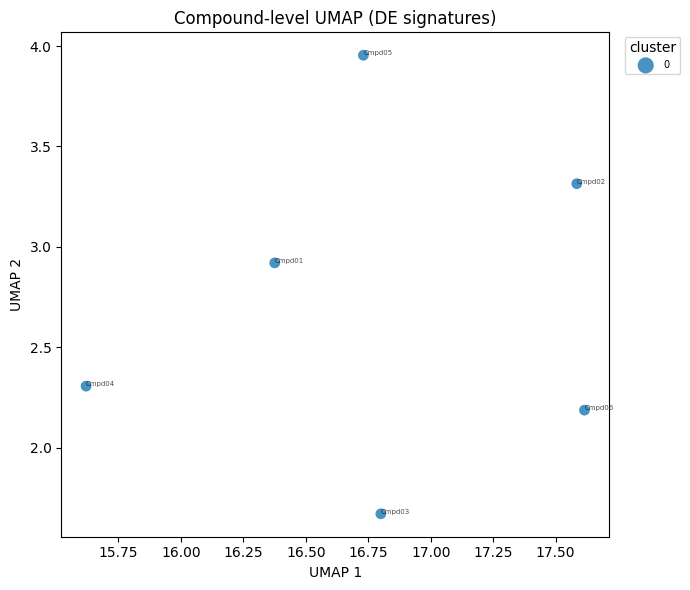

  compound     UMAP_1    UMAP_2 cluster
0   Cmpd01  16.375462  2.920228       0
1   Cmpd02  17.584435  3.314498       0
2   Cmpd03  16.800142  1.670840       0
3   Cmpd04  15.620287  2.306442       0
4   Cmpd05  16.730244  3.954003       0
5   Cmpd06  17.615234  2.186937       0


In [20]:
try:
    umap_df = ds.compute_compound_umap(
        dsd, n_pcs=5, n_variable_genes=200,
        n_neighbors=3, min_dist=0.3,
        use_leiden=True, resolution=0.8,
    )
    fig = ds.plot_compound_umap(umap_df, color_by='cluster', label_compounds=True)
    plt.show()
    print(umap_df)
except Exception as e:
    print(f'Compound UMAP skipped (need umap-learn): {e}')

## 10. GSEA

Requires gseapy. Uses gseapy.prerank on the per-compound DE ranking.

In [21]:
try:
    # Using a custom gene set for reproducibility (replace with MSigDB shorthand
    # like 'MSigDB_Hallmark_2020' in real analyses)
    all_genes = dsd.var_names.tolist()
    custom_sets = {
        'GeneModule_A': all_genes[:30],
        'GeneModule_B': all_genes[30:60],
        'GeneModule_C': all_genes[60:90],
    }
    ds.run_gsea(dsd, gene_sets=custom_sets, n_perm=200, min_size=10, inplace=True)
    # Show results for first compound
    cmpd = list(dsd.adata.uns['de_results'].keys())[0]
    print(f'GSEA for {cmpd}:')
    print(dsd.adata.uns['gsea'][cmpd][['Term','NES','NOM p-val','FDR q-val']].head(10))
except Exception as e:
    print(f'GSEA skipped: {e}')

Running GSEA for 6 compound(s), 3 gene sets.
GSEA complete for 6 compound(s).
GSEA for Cmpd01:
           Term                 NES           NOM p-val           FDR q-val
0  GeneModule_A  2.4127523135890843                 0.0                 0.0
1  GeneModule_C  -0.783723821557757  0.8133333333333334                 0.8
2  GeneModule_B  0.7227955492707664  0.8174603174603174  0.8263157894736842


/Users/frankhuang/Documents/HKU-RA/01.Library-Seq/20260317/drugseqpy/src/drugseqpy/enrichment.py:34: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna("").astype(str)
/Users/frankhuang/Documents/HKU-RA/01.Library-Seq/20260317/drugseqpy/src/drugseqpy/enrichment.py:34: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna("").astype(str)
/Users/frankhuang/Documents/HKU-RA/01.Library-Seq/20260317/drugseqpy/src/drugseqpy/enrichment.py:34: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprec

In [22]:
dsd.adata.uns["gsea"]

{'Cmpd01':       Name          Term                   ES                 NES  \
 0  prerank  GeneModule_A   0.8265460030072485  2.4127523135890843   
 1  prerank  GeneModule_C  -0.2250872560526574  -0.783723821557757   
 2  prerank  GeneModule_B  0.25183653192539457  0.7227955492707664   
 
             NOM p-val           FDR q-val          FWER p-val  Tag %  Gene %  \
 0                 0.0                 0.0                 0.0  10/30   2.02%   
 1  0.8133333333333334                 0.8  0.8636363636363636   5/30  14.92%   
 2  0.8174603174603174  0.8263157894736842                0.92   8/30  20.77%   
 
                                           Lead_genes  
 0  Gene0007;Gene0002;Gene0003;Gene0010;Gene0004;G...  
 1       Gene0070;Gene0045;Gene0062;Gene0048;Gene0059  
 2  Gene0039;Gene0032;Gene0026;Gene0033;Gene0038;G...  ,
 'Cmpd02':       Name          Term                  ES                 NES  \
 0  prerank  GeneModule_B  0.8222554341857794  2.2588875488297746   
 1  prera

In [23]:
ds.run_go_enrichment(dsd, species= "Human")

Running GO enrichment for 6 compound(s)...
GO enrichment complete. Results stored in adata.uns['go'].


/Users/frankhuang/Documents/HKU-RA/01.Library-Seq/20260317/drugseqpy/src/drugseqpy/enrichment.py:341: UserWarning:   GO enrichment failed for 'Cmpd01': Invalid organism 'Human'. Valid options are: c. elegans, caenorhabditis elegans, celegans, d. melanogaster, d. rerio, danio rerio, drosophila, drosophila melanogaster, enrichr, fish, fly, h. sapiens, homo sapiens, hs, hsapiens, human, m. musculus, mm, mouse, mus musculus, nematode, s. cerevisiae, saccharomyces, saccharomyces cerevisiae, worm, yeast, zebrafish
  warnings.warn(f"  GO enrichment failed for '{cmpd}': {e}")
/Users/frankhuang/Documents/HKU-RA/01.Library-Seq/20260317/drugseqpy/src/drugseqpy/enrichment.py:341: UserWarning:   GO enrichment failed for 'Cmpd02': Invalid organism 'Human'. Valid options are: c. elegans, caenorhabditis elegans, celegans, d. melanogaster, d. rerio, danio rerio, drosophila, drosophila melanogaster, enrichr, fish, fly, h. sapiens, homo sapiens, hs, hsapiens, human, m. musculus, mm, mouse, mus musculus, 

In [27]:
dsd.adata.uns["go"]

{}

## 11. Save results

In [28]:
dsd.write('dsd_screen_results.h5ad')
print('Saved: dsd_screen_results.h5ad')

# Export DE summary to CSV
de_sum = ds.summarise_de(dsd)
de_sum.to_csv('de_summary.csv', index=False)
print('Saved: de_summary.csv')

Saved: dsd_screen_results.h5ad
Saved: de_summary.csv


---
**Next →** `03_Dose_Response_Cheminformatics.ipynb`